# Data Cleaning: Titanic Dataset Analysis
This notebook will walk through the steps of loading, cleaning, and performing basic exploratory data analysis on the Titanic dataset.

![Machine Learning Lifecycle](machine_learning_lifecycle.webp)

## Import necessary libraries

In [2]:
import pandas as pd

## <br>Step 1: Load the dataset
We use pandas to load the Titanic dataset into a DataFrame.

In [3]:
# Assuming the CSV is in the same directory as this notebook
csv_path = 'Titanic-Dataset.csv'
df = pd.read_csv(csv_path)
print("Dataset loaded successfully!")

# Display general information
print("\nDataset Info:")
df.info()

# Display first 5 rows
print("\nFirst 5 rows:")
df.head()

Dataset loaded successfully!

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## <br>Step 2: Check for Duplicate Rows

In [3]:
print("\nChecking for duplicate rows:")
print(df.duplicated())
print("\nNumber of duplicate rows: ", df.duplicated().sum())


Checking for duplicate rows:
0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Length: 891, dtype: bool

Number of duplicate rows:  0


## <br>Step 3: Identify Column Data Types

In [4]:
cat_col = [col for col in df.columns if df[col].dtype == 'object']
num_col = [col for col in df.columns if df[col].dtype != 'object']

print("\n")
print("Categorical Columns: ", cat_col)
print("Numerical Columns:   ", num_col)



Categorical Columns:  ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
Numerical Columns:    ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


## <br>Step 4: Analyze Categorical Columns

In [5]:
print(df[cat_col].nunique())
print("\nCategorical Columns Size: ", df[cat_col].size)

Name        891
Sex           2
Ticket      681
Cabin       147
Embarked      3
dtype: int64

Categorical Columns Size:  4455


## <br>Step 5: Calculate Missing Values as Percentage

In [6]:
print(df.isnull().sum(), "\n")
print(df.shape)
print(df.shape[0], "\n")
print(round(df.isnull().sum() / df.shape[0] * 100, 2), "\n")

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64 

(891, 12)
891 

PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64 



## <br>Step 6: Drop Irrelevant or Data-Heavy Missing Columns
We drop `Cabin`, `Ticket`, and `Name` columns. Then handle missing `Embarked` and `Age` values.


In [7]:
# axis=0 --> drop rows
# axis=1 --> drop columns
df1 = df.drop(['Cabin', 'Ticket', 'Name'], axis=1)

# Inplace modifies the DataFrame in place rather than returning a new DataFrame.
df1.dropna(subset=['Embarked'], inplace=True)   # Drop rows where 'Embarked' is NaN
df1['Age'] = df1['Age'].fillna(df1['Age'].mean())

df1.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S


## <br>Step 7: Detect Outliers with Box Plot
IQR:     https://www.geeksforgeeks.org/maths/interquartile-range/

BoxPlot: https://www.geeksforgeeks.org/machine-learning/box-plot/

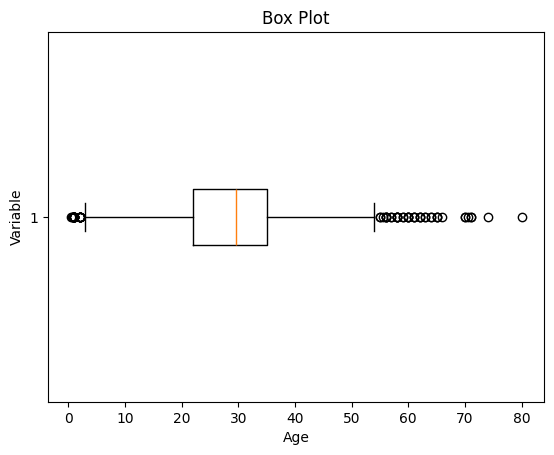

In [8]:
import matplotlib.pyplot as plt

df3 = df1.copy()
before_outliers_cleaning = df1.copy()

plt.boxplot(df3['Age'], vert=False)
plt.ylabel('Variable')
plt.xlabel('Age')
plt.title('Box Plot')

plt.show()

## <br>Step 8: Calculate Outlier Boundaries and Remove Them
Define bounds as mean ± 2 * std for outlier detection.

<img src="normal-distribution.png" alt="Normal Distribution" width="500">

In [17]:
mean = df1["Age"].mean()
std = df1["Age"].std()
print("Mean: ", round(mean, 2))
print("Standard Deviation: ", round(std, 2))

lower_bound = mean - 2 * std
upper_bound = mean + 2 * std
print("Lower Bound: ", round(lower_bound, 2))
print("Upper Bound: ", round(upper_bound, 2))

outliears = df1[(df1["Age"] < lower_bound) | (df1["Age"] > upper_bound)]
print("Number of outliers in Age: ", outliears["Age"].count())

df2 = df1[(df1["Age"] >= lower_bound) & (df1["Age"] <= upper_bound)]
df2.head()

Mean:  29.64
Standard Deviation:  12.97
Lower Bound:  3.71
Upper Bound:  55.58
Number of outliers in Age:  68


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S


## <br> Step 9: Impute Missing Data Again if Any
fillna() applied again on filtered data to handle any remaining missing values.

In [18]:
df3 = df2.fillna(df2["Age"].mean())
print(df3.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64


### Comparing Results

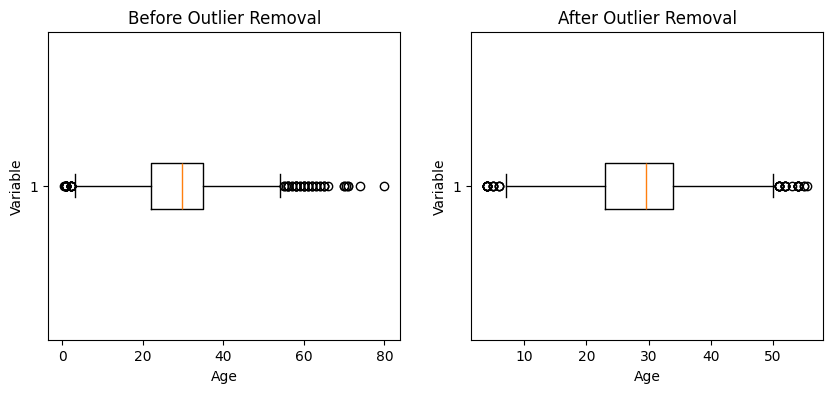

In [11]:
before_outliers_cleaning = df1.copy()

# The first two parameters (1, 2) specify the number of rows and columns of subplots, respectively.
# figsize specifies the overall size of the figure in inches.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].boxplot(before_outliers_cleaning['Age'], vert=False)
axes[0].set_title('Before Outlier Removal')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Variable')

axes[1].boxplot(df3['Age'], vert=False)
axes[1].set_title('After Outlier Removal')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Variable')

plt.show()

## <br>Step 10: Recalculate Outlier Bounds and Remove Outliers

In this step, we identify and remove outliers from the **Age** column using two statistical methods.

---

### When should we use each method?

- **Mean ± 2 × Standard Deviation**: best when the feature is **roughly symmetric / close to normal**. It is easy to interpret (like a simple “z-score” rule), but it is **sensitive to extreme values** because both the mean and standard deviation can be pulled by outliers.

- **Median + IQR**: best when the feature is **skewed, has heavy tails, or contains extreme values**. Median and IQR are **robust** statistics, so this method is usually more stable when there are strong outliers.

### Why don’t we use only IQR?

We don’t use IQR only because **no single rule works best for every distribution**:

- The **1.5 × IQR** cutoff is a **heuristic**; it can be **too strict or too loose** depending on the feature’s shape and the sample size.
- For (approximately) **normal** data, IQR and STD rules flag **different amounts** of data (they’re not equivalent), so relying on only one method can hide or over-remove points.
- In real datasets, some “outliers” are **valid rare cases** (not errors). Comparing both methods + visually checking (boxplot/histogram) helps you avoid deleting useful information.

---

### Method 1: Mean ± 2 × Standard Deviation

1. **`mean = df1["Age"].mean()`**  
   Calculates the arithmetic mean (average) of the `Age` values.

2. **`std = df1["Age"].std()`**  
   Computes the standard deviation, which measures how much the `Age` values vary around the mean.

3. **`lower_bound_std = mean - 2 * std`**  
   Defines the lower acceptable limit as two standard deviations below the mean.

4. **`upper_bound_std = mean + 2 * std`**  
   Defines the upper acceptable limit as two standard deviations above the mean.

5. **`df_std = df1[(Age >= lower_bound_std) & (Age <= upper_bound_std)]`**  
   Creates a cleaned DataFrame by keeping only `Age` values within the calculated bounds, removing extreme outliers.

---

### Method 2: Median + Interquartile Range (IQR)

1. **`median = df1["Age"].median()`**  
   Calculates the median (middle value) of the `Age` column.

2. **`Q1` and `Q3`**  
   - `Q1` (25th percentile)  
   - `Q3` (75th percentile)

3. **`IQR = Q3 - Q1`**  
   Measures the spread of the middle 50% of the data.

4. **`lower_bound_iqr = Q1 - 1.5 * IQR`**  
   Defines the lower outlier threshold.

5. **`upper_bound_iqr = Q3 + 1.5 * IQR`**  
   Defines the upper outlier threshold.

6. **`df_iqr = df1[(Age >= lower_bound_iqr) & (Age <= upper_bound_iqr)]`**  
   Creates a cleaned DataFrame by removing outliers based on the IQR rule.

---

### Visualization

- The **left box plot** shows the data after outlier removal using **Mean ± 2·STD**.
- The **right box plot** shows the data after outlier removal using **Median + IQR**.

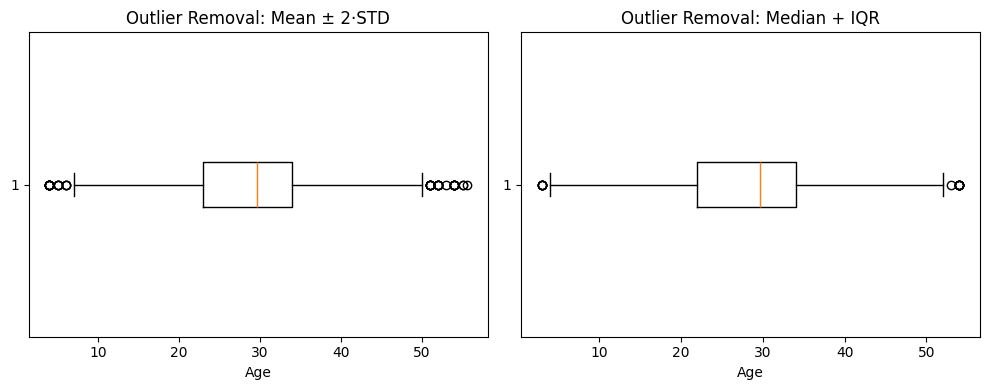

In [ ]:
# ===============================
# Method 1: Mean ± 2 * Standard Deviation
# ===============================

mean = df1["Age"].mean()
std = df1["Age"].std()

lower_bound_std = mean - 2 * std
upper_bound_std = mean + 2 * std

df_std = df1[
    (df1["Age"] >= lower_bound_std) &
    (df1["Age"] <= upper_bound_std)
]

# ===============================
# Method 2: Median + IQR
# ===============================

median = df1["Age"].median()
Q1 = df1["Age"].quantile(0.25)
Q3 = df1["Age"].quantile(0.75)
IQR = Q3 - Q1

lower_bound_iqr = Q1 - 1.5 * IQR
upper_bound_iqr = Q3 + 1.5 * IQR

df_iqr = df1[
    (df1["Age"] >= lower_bound_iqr) &
    (df1["Age"] <= upper_bound_iqr)
]

# ===============================
# Visualization
# ===============================

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Mean ± STD cleaned boxplot
axes[0].boxplot(df_std["Age"], vert=False)
axes[0].set_title("Outlier Removal: Mean ± 2·STD")
axes[0].set_xlabel("Age")

# IQR cleaned boxplot
axes[1].boxplot(df_iqr["Age"], vert=False)
axes[1].set_title("Outlier Removal: Median + IQR")
axes[1].set_xlabel("Age")

plt.tight_layout()
plt.show()

## <br>Step 11: Data validation and verification
### Data Validation, Verification, and Feature Selection

**Data validation and verification**  
This means checking that the data is correct and consistent, often by comparing it with trusted sources or expert knowledge.

**Machine Learning Feature Setup**  
For machine learning, we split the data into:

- **Independent features** (inputs the model uses to make predictions)
- **Target variable** (what we want to predict)

**In this example:**

- **Independent features:** `Sex`, `Age`, `SibSp`, `Parch`, `Fare`, `Embarked`  
- **Target variable:** `Survived`  
- **Excluded feature:** `PassengerId` (it doesn’t affect survival)


In [13]:
X = df3[['Pclass','Sex','Age', 'SibSp','Parch','Fare','Embarked']]
Y = df3['Survived']

print(X.head(), "\n")
print(Y.head())

   Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0       3    male  22.0      1      0   7.2500        S
1       1  female  38.0      1      0  71.2833        C
2       3  female  26.0      0      0   7.9250        S
3       1  female  35.0      1      0  53.1000        S
4       3    male  35.0      0      0   8.0500        S 

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64
